# PCA Image Compression — MNIST digits 0 / 1 / 2

PCA is a lossy image codec. Keep only the top `k` principal components and each
784-pixel digit is stored as just `k` numbers (its *code*); the decoder maps
those codes back to pixels. Small `k` -> tiny codes (big **compression ratio**)
but blurry reconstructions; large `k` -> near-perfect images but little saving.

This notebook studies that **quality-vs-size trade-off** using the helpers in
[`utils/pca/compression.py`](../utils/pca/compression.py).

In [1]:
import sys
from pathlib import Path

# Make src/ importable regardless of the launch cwd.
for cand in (Path.cwd(), *Path.cwd().parents):
    if (cand / "utils" / "mnist_data.py").exists():
        sys.path.insert(0, str(cand)); break
    if (cand / "src" / "utils" / "mnist_data.py").exists():
        sys.path.insert(0, str(cand / "src")); break

import numpy as np
import matplotlib.pyplot as plt

from utils.mnist_data import load_digits, as_images, DIGITS, N_FEATURES
from utils.pca.compression import (
    fit_pca, compress, reconstruct, reconstruction_error, compression_ratio,
)

DIGITS, N_FEATURES

((0, 1, 2), 784)

## Load the data

Digits 0/1/2, 1000 samples per class, as a flat `(n, 784)` matrix scaled to
`[0, 1]` — the shared contract from `utils.mnist_data`.

In [2]:
X, y = load_digits(per_class=1000)
print("X", X.shape, X.dtype, "range", (float(X.min()), float(X.max())))
print("classes", sorted(set(y.tolist())))

I0000 00:00:1783949710.435283   47548 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783949710.490083   47548 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1783949711.942316   47548 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


X (3000, 784) float32 range (0.0, 1.0)
classes [0, 1, 2]


## Reconstruct sample digits at several component counts

We fit one PCA per component count `k`, encode a handful of sample digits to
`k`-number codes, then decode them back to images. Reading top-to-bottom shows
detail returning as `k` grows.

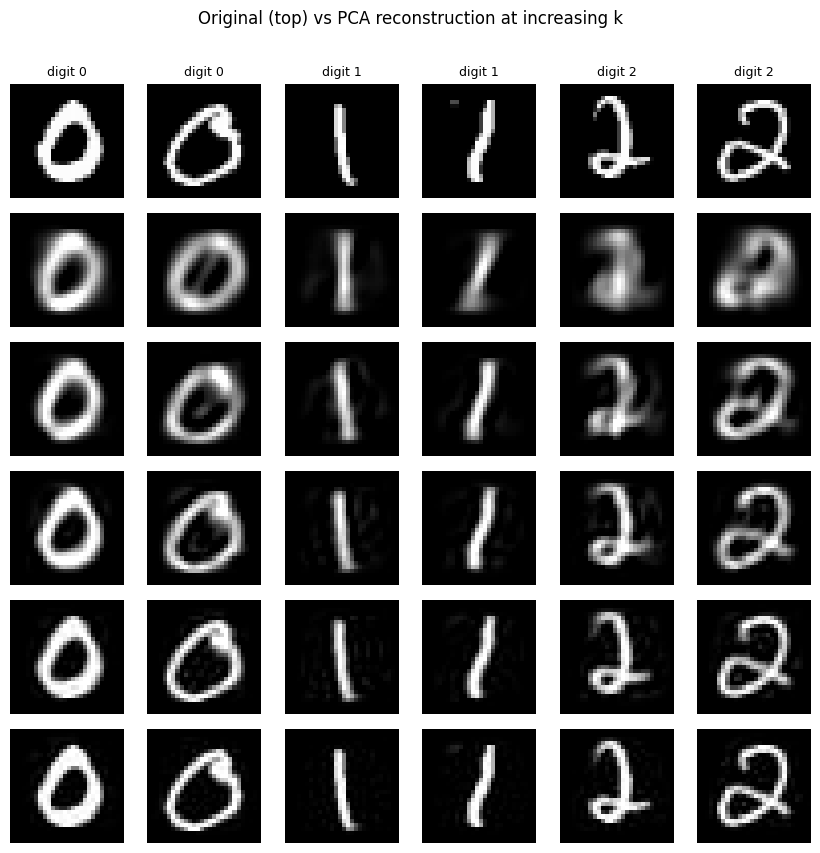

In [3]:
KS = [5, 20, 50, 100, 200]

# Pick a few sample images (one of each digit if possible).
rng = np.random.default_rng(0)
sample_idx = []
for d in DIGITS:
    pool = np.flatnonzero(y == d)
    sample_idx.extend(rng.choice(pool, size=2, replace=False))
sample_idx = np.array(sample_idx)
X_samp = X[sample_idx]

# Encode/decode the samples at every k (fit on the full X for each k).
recons = {}
for k in KS:
    pca = fit_pca(X, k)
    codes = compress(pca, X_samp)
    recons[k] = reconstruct(pca, codes)

n_show = len(sample_idx)
rows = len(KS) + 1
fig, axes = plt.subplots(rows, n_show, figsize=(1.4 * n_show, 1.4 * rows))
for j in range(n_show):
    axes[0, j].imshow(as_images(X_samp[j:j+1])[0], cmap="gray")
    axes[0, j].set_title(f"digit {y[sample_idx[j]]}", fontsize=9)
    axes[0, j].axis("off")
for i, k in enumerate(KS, start=1):
    for j in range(n_show):
        axes[i, j].imshow(as_images(recons[k][j:j+1])[0], cmap="gray")
        axes[i, j].axis("off")
    axes[i, 0].set_ylabel(f"k={k}", rotation=0, ha="right", va="center", fontsize=10)
axes[0, 0].set_ylabel("original", rotation=0, ha="right", va="center", fontsize=10)
fig.suptitle("Original (top) vs PCA reconstruction at increasing k", y=1.01)
plt.tight_layout()
plt.show()

At `k=5` the digits are barely legible smudges; by `k=50` they are clearly
readable, and `k=200` is visually almost indistinguishable from the originals.

## Quality vs. size across a sweep of k

For each `k` we fit PCA on all 3000 images, reconstruct the whole set, and record
the per-pixel reconstruction MSE and the compression ratio `784 / k`.

In [4]:
K_SWEEP = [1, 2, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 400]

mses, ratios = [], []
for k in K_SWEEP:
    pca = fit_pca(X, k)
    X_hat = reconstruct(pca, compress(pca, X))
    mses.append(reconstruction_error(X, X_hat))
    ratios.append(compression_ratio(k))

for k, m, r in zip(K_SWEEP, mses, ratios):
    print(f"k={k:>3}  ratio={r:6.2f}x  MSE={m:.5f}")

k=  1  ratio=784.00x  MSE=0.05357
k=  2  ratio=392.00x  MSE=0.04716
k=  5  ratio=156.80x  MSE=0.03557
k= 10  ratio= 78.40x  MSE=0.02605
k= 20  ratio= 39.20x  MSE=0.01721
k= 30  ratio= 26.13x  MSE=0.01247
k= 50  ratio= 15.68x  MSE=0.00773
k= 75  ratio= 10.45x  MSE=0.00497
k=100  ratio=  7.84x  MSE=0.00351
k=150  ratio=  5.23x  MSE=0.00198
k=200  ratio=  3.92x  MSE=0.00117
k=300  ratio=  2.61x  MSE=0.00039
k=400  ratio=  1.96x  MSE=0.00008


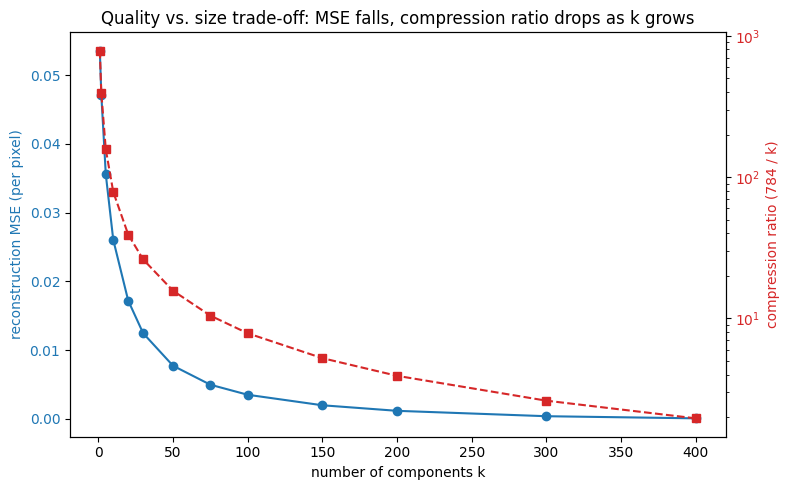

In [5]:
fig, ax1 = plt.subplots(figsize=(8, 5))

color1 = "tab:blue"
ax1.plot(K_SWEEP, mses, "o-", color=color1, label="reconstruction MSE")
ax1.set_xlabel("number of components k")
ax1.set_ylabel("reconstruction MSE (per pixel)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.plot(K_SWEEP, ratios, "s--", color=color2, label="compression ratio")
ax2.set_ylabel("compression ratio (784 / k)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_yscale("log")

ax1.set_title("Quality vs. size trade-off: MSE falls, compression ratio drops as k grows")
fig.tight_layout()
plt.show()

## Interpretation & a "good enough" k

The two curves move in opposite directions:

- **Reconstruction MSE** falls steeply for the first ~50 components, then
  flattens into diminishing returns — the leading components capture the bulk of
  the digit structure (strokes, orientation), later ones only fine texture.
- **Compression ratio** is `784 / k`, so it plummets as we add components: going
  from `k=50` (≈16x smaller) to `k=200` (≈4x smaller) quadruples storage for only
  a small MSE improvement.

**Sweet spot: k ≈ 50.** It sits at the elbow of the MSE curve — reconstructions
are clearly legible (see the image grid) — while still giving roughly a **16x**
reduction in stored numbers per image. If quality matters more than size,
`k ≈ 100` (≈8x, visually crisp) is a reasonable step up; below `k ≈ 20` the
savings are large but digits start to blur together.